In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
%matplotlib inline



words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [25]:
N = torch.zeros((27,27),dtype = torch.int32)

chars = sorted(list(set(''.join(words))))
stoi = { s:i+1 for i,s in enumerate(chars)}
stoi ['.']=0
itos = {i:s for s,i in stoi.items()}

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] +=1
#模型平滑，确保不会出现频率为0的计数值，为使用负对数最大似然估计法提供便利，既不会出现无穷大
N +=1


(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

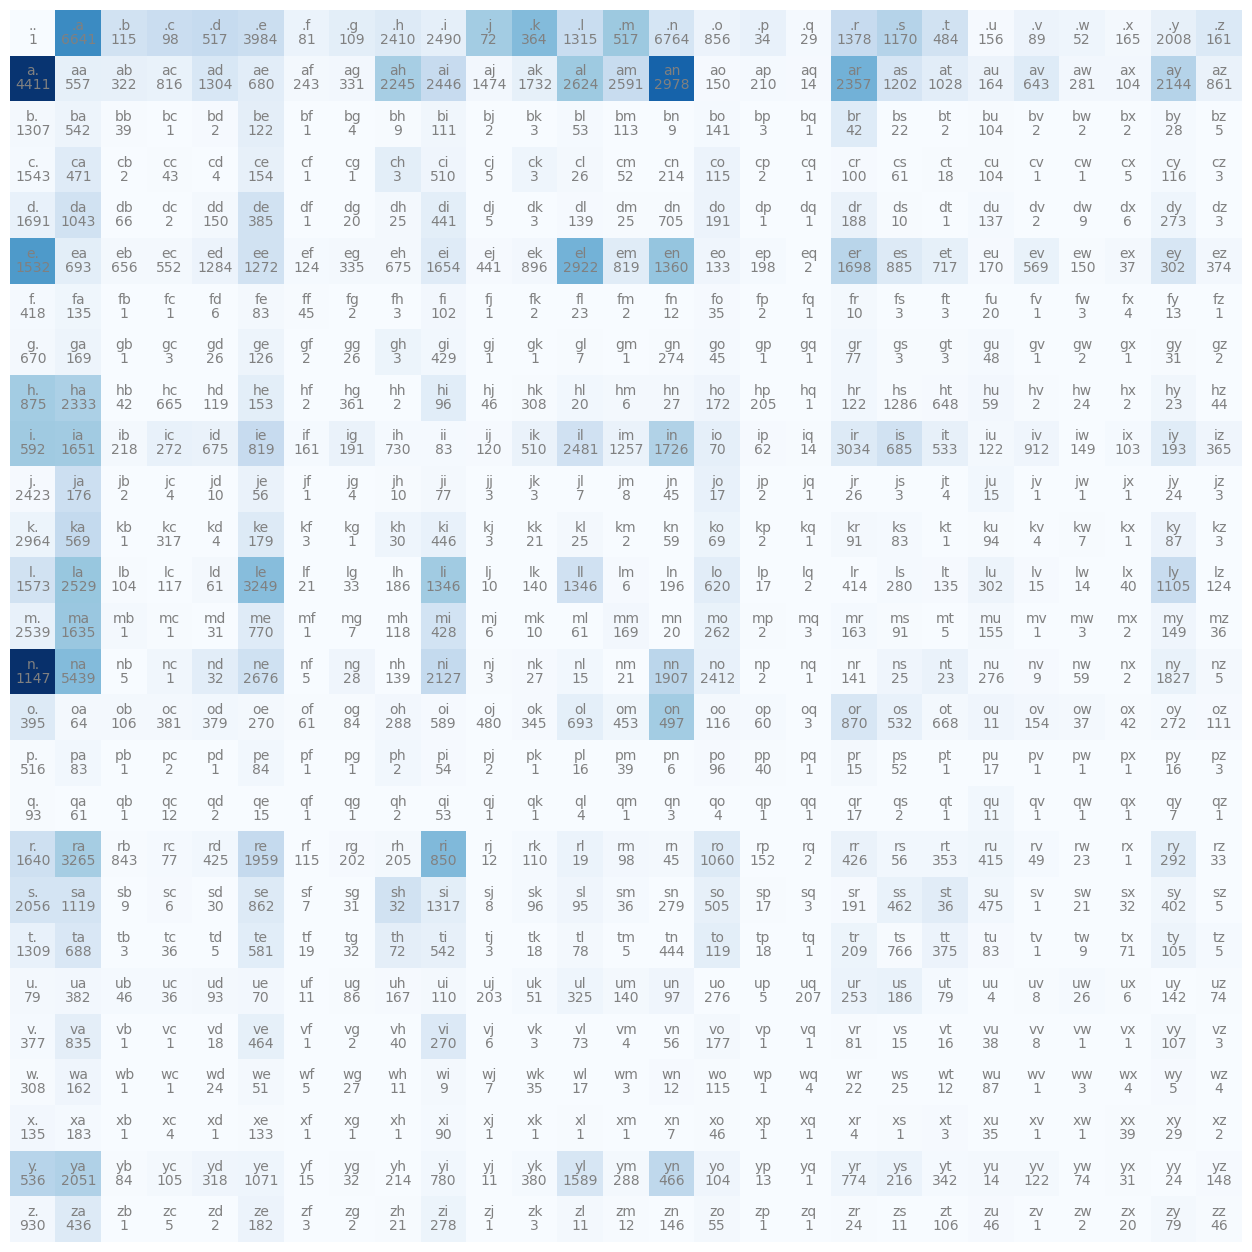

In [26]:
plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j,i,chstr,ha="center",va="bottom",color='gray')
        plt.text(i,j,N[i,j].item(),ha="center",va="top",color='gray')
plt.axis('off')

In [18]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [31]:
g = torch.Generator().manual_seed(2147483647)
P = N.float()
P = P / P.sum(1, keepdims = True)
for i in range(20):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p,num_samples=1,replacement = True,generator = g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


In [32]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
nll = -log_likelihood
print(f'{nll}')
print(f'{nll/n}')

559951.5625
2.4543561935424805


In [50]:
# create the training set of bigrams (x,y)

xs,ys = [],[]
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

num = xs.nelement()
print('number of examples:',num)




number of examples: 5


In [36]:
xs

tensor([ 0,  5, 13, 13,  1])

In [37]:
ys

tensor([ 5, 13, 13,  1,  0])

In [39]:
# onehot编码
import torch.nn.functional as F
xenc = F.one_hot(xs,num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [41]:
xenc.shape

torch.Size([5, 27])

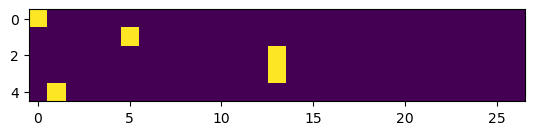

In [42]:
plt.imshow(xenc)

In [45]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27),generator = g)
logits = xenc @ W # log_counts
counts = logits.exp()
probs = counts / counts.sum(1,keepdims =True)
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [46]:
probs.shape

torch.Size([5, 27])

In [49]:
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()

    p = probs[i,y]
    logp = torch.log(p)
    nll = -logp
    print('negative log likelihood:',nll.item())
    nlls[i] =nll
print('=========')
print('average negative log likelihood,i.e. loss =',nlls.mean().item())

negative log likelihood: 4.399273872375488
negative log likelihood: 4.014570713043213
negative log likelihood: 3.623408794403076
negative log likelihood: 2.6080665588378906
negative log likelihood: 4.201204299926758
average negative log likelihood,i.e. loss = 3.7693049907684326


In [56]:
import torch.nn.functional as F

xs,ys = [],[]
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

num = xs.nelement()
print('number of examples:',num)

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27),generator = g,requires_grad = True)

number of examples: 228146


In [63]:
for k in range(10):
    #forward pass
    xenc = F.one_hot(xs,num_classes=27).float()
    logits = xenc @ W # log_counts
    counts = logits.exp()
    probs = counts / counts.sum(1,keepdims =True)
    loss = -probs[torch.arange(num),ys].log().mean() + 0.01*(W**2).mean()

    print(loss.item())

    #backward pass
    W.grad = None
    loss.backward()

    #update
    W.data += -50* W.grad

2.490612506866455
2.490525007247925
2.490440607070923
2.4903576374053955
2.4902775287628174
2.4901983737945557
2.4901211261749268
2.4900448322296143
2.4899699687957764
2.489895820617676
